In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
t2m_data = pd.read_csv('D:/Apy0/data/T2M/ts_T2M_2000_2024_grid_R0_C0.csv')
tpmm_data = pd.read_csv('D:/Apy0/data/tpmm/ts_tp_2000_2024_grid_R0_C0.csv')
ds_data = pd.DataFrame(
    {
        'Date': t2m_data['date'],
        'T2M': t2m_data['ts_sel_season'],
        'tpmm': tpmm_data['pcpmm']
    }
)
ds_data

,Date,T2M,tpmm
0,2000-01-01,-8.497437,0.774860
1,2000-01-02,-11.989685,1.519203
2,2000-01-03,-14.372162,1.357555
3,2000-01-04,-16.527680,0.380039
4,2000-01-05,-8.181915,2.262592
...,...,...,...
9127,2024-12-27,-0.699341,0.942230
9128,2024-12-28,-3.081360,0.106812
9129,2024-12-29,-8.211334,0.263214
9130,2024-12-30,-6.311249,1.698494


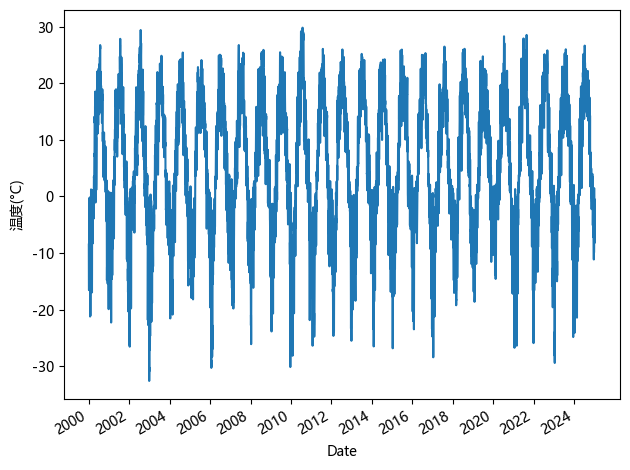

In [4]:
fig, ax = plt.subplots()

ax.plot(t2m_data['ts_sel_season'])
ax.set_xlabel('Date')
ax.set_ylabel('温度(°C)')

plt.xticks(np.arange(0, 9200, 730), np.arange(2000, 2025, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('fig/CH09_F01_peixeiro.png', dpi=300)

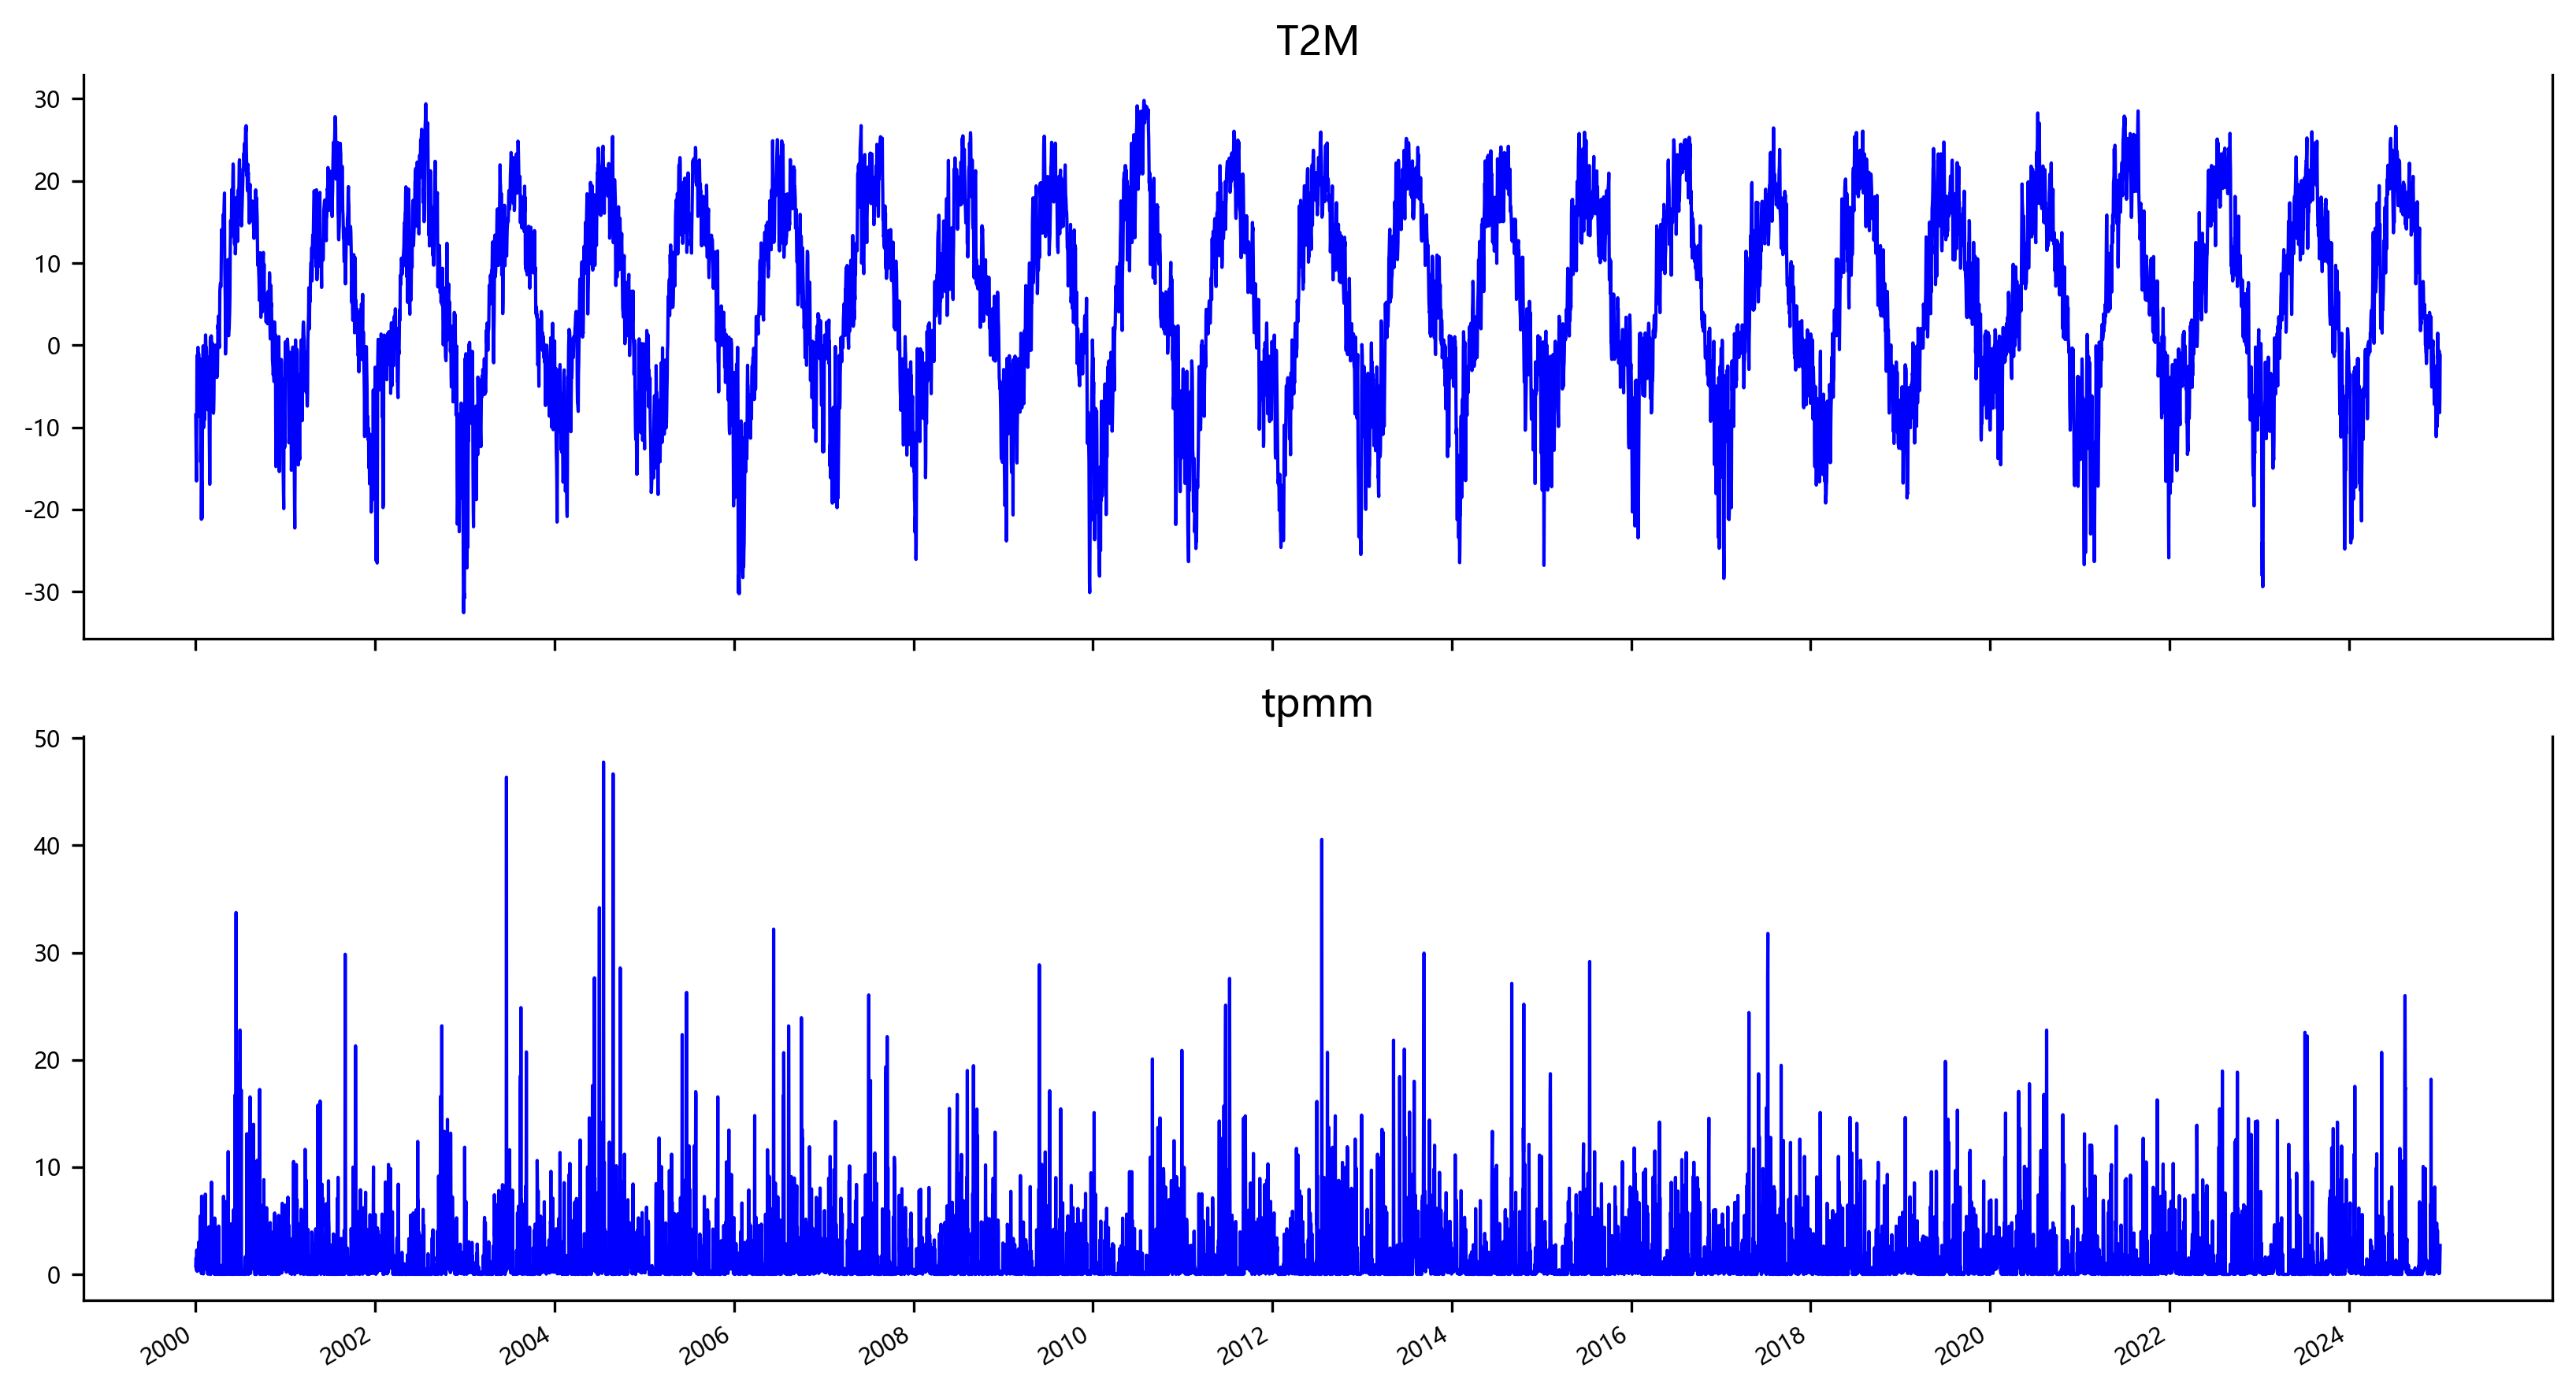

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=1, dpi=300, figsize=(11,6))

for i, ax in enumerate(axes.flatten()[:3]):
    data = ds_data[ds_data.columns[i+1]]
    
    ax.plot(data, color='blue', linewidth=1)
    ax.set_title(ds_data.columns[i+1])
    # ax.xaxis.set_ticks_position('none')
    # ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    # ax.spines['right'].set_alpha(0)
    ax.tick_params(labelsize=7)

plt.setp(axes, xticks=np.arange(0, 9200, 730), xticklabels=np.arange(2000, 2025, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig/CH09_F02_peixeiro.png', dpi=300)

In [8]:
target = ds_data['T2M']
exog = ds_data[['tpmm']]

In [9]:
ad_fuller_result = adfuller(target)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -6.158088319278252
p-value: 7.285569244768037e-08


In [10]:
target_diff = target.diff()

ad_fuller_result = adfuller(target_diff[1:])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -28.74992400838115
p-value: 0.0


In [11]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [12]:
p = range(0, 4, 1)
d = 1
q = range(0, 4, 1)
P = range(0, 4, 1)
D = 0
Q = range(0, 4, 1)
s = 12

parameters = product(p, q, P, Q)
parameters_list = list(parameters)

In [13]:
target_train = target[:200]
exog_train = exog[:200]

result_df = optimize_SARIMAX(target_train, exog_train, parameters_list, d, D, s)
result_df

100%|██████████| 256/256 [08:01<00:00,  1.88s/it]


,"(p,q,P,Q)",AIC
0,"(3, 3, 0, 0)",975.172202
1,"(3, 3, 0, 1)",977.168929
2,"(3, 3, 1, 0)",977.169035
3,"(3, 3, 2, 0)",979.118415
4,"(3, 3, 0, 2)",979.129641
...,...,...
251,"(0, 0, 1, 3)",1002.700054
252,"(0, 0, 2, 2)",1003.149410
253,"(0, 0, 2, 3)",1003.651840
254,"(0, 0, 3, 3)",1004.512574


In [14]:
best_model = SARIMAX(target_train, exog_train, order=(3,1,3), seasonal_order=(0,0,0,12), simple_differencing=False)
best_model_fit = best_model.fit(disp=False)

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    T2M   No. Observations:                  200
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -479.586
Date:                Fri, 22 May 2026   AIC                            975.172
Time:                        07:16:05   BIC                           1001.519
Sample:                             0   HQIC                           985.835
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
tpmm           0.0084      0.046      0.183      0.855      -0.082       0.099
ar.L1         -0.7881      0.090     -8.746      0.000      -0.965      -0.611
ar.L2          0.6291      0.140      4.481      0.0

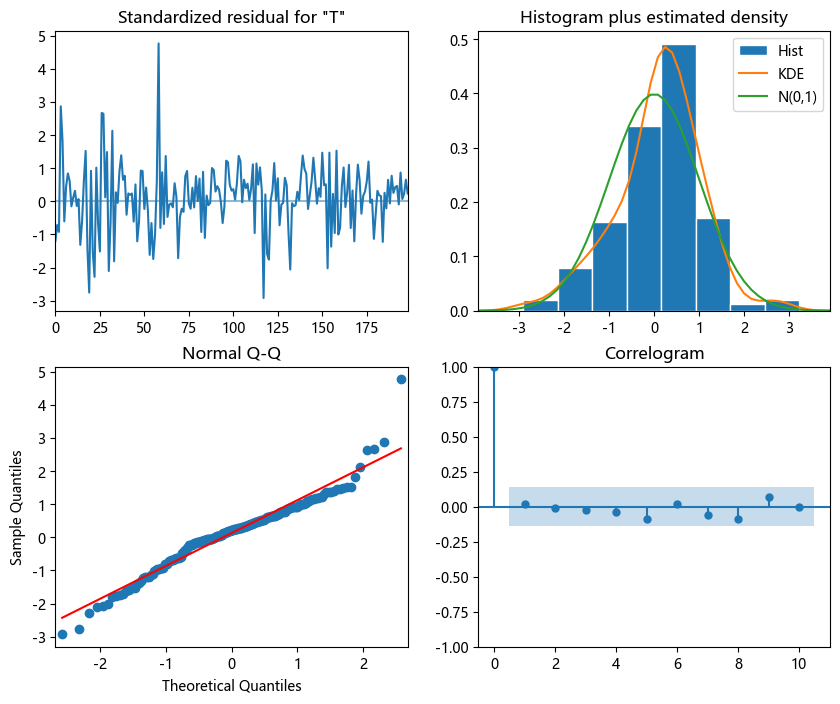

In [15]:
best_model_fit.plot_diagnostics(figsize=(10,8))

plt.savefig('fig/CH09_F05_peixeiro.png', dpi=300)

In [19]:
residuals = best_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(pvalue)

lb_pvalue


In [20]:
def recursive_forecast(endog: Union[pd.Series, list], exog: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = endog[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'SARIMAX':
        pred_SARIMAX = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order=(3,1,3), seasonal_order=(0,0,0,12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMAX.extend(oos_pred)
            
        return pred_SARIMAX

In [21]:
target_train = target[:7300]
target_test = target[7300:]

pred_df = pd.DataFrame({'actual': target_test})

TRAIN_LEN = len(target_train)
HORIZON = len(target_test)
WINDOW = 1

pred_last_value = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX

pred_df

KeyboardInterrupt: 

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
mape_last = mape(pred_df.actual, pred_df.pred_last_value)
mape_SARIMAX = mape(pred_df.actual, pred_df.pred_SARIMAX)

print(mape_last, mape_SARIMAX)

In [ ]:
fig, ax = plt.subplots()

x = ['naive last value', 'SARIMAX']
y = [mape_last, mape_SARIMAX]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 1)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.05, s=str(round(value,2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH09_F06_peixeiro.png', dpi=300)